 # Assignment 1




---

## Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# Set plotting style for better visualization
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

---
# Question 1: Ideal Gas Law and Isotherms

The Ideal Gas Law is given by: **PV = nRT**

Where:
- P = Pressure (Pa)
- V = Volume (m³)
- n = Number of moles (mol)
- R = Universal gas constant = 8.314 J/(mol·K)
- T = Temperature (K)

### Part (a): Create Pressure Function

In [2]:
def calculate_pressure(temperature, volume, n=1, R=8.314):
    """
    Calculate pressure using the Ideal Gas Law: P = nRT/V

    Parameters:
    -----------
    temperature : float
        Temperature in Kelvin (K)
    volume : float or array
        Volume in cubic meters (m³)
    n : float, optional
        Number of moles (default = 1 mol)
    R : float, optional
        Universal gas constant in J/(mol·K) (default = 8.314)

    Returns:
    --------
    pressure : float or array
        Pressure in Pascals (Pa)
    """
    pressure = (n * R * temperature) / volume
    return pressure

# Test the function
test_pressure = calculate_pressure(temperature=300, volume=1)
print(f"Test: At T=300K and V=1m³, Pressure = {test_pressure:.2f} Pa")

Test: At T=300K and V=1m³, Pressure = 2494.20 Pa


### Part (b): Plot Isotherms

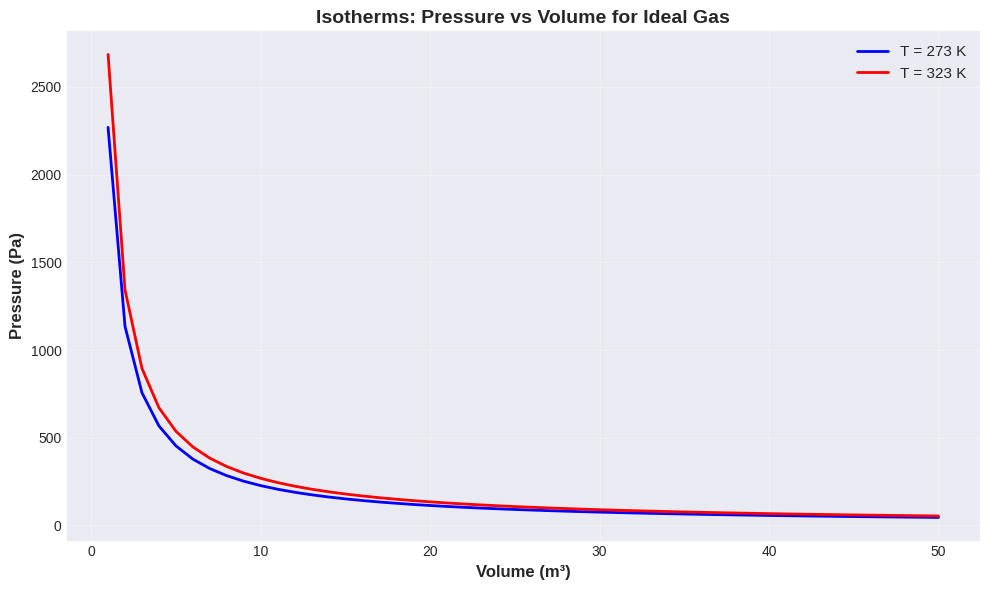

Isotherm at 273K: Pressure ranges from 2269.72 to 45.39 Pa
Isotherm at 323K: Pressure ranges from 2685.42 to 53.71 Pa


In [3]:
# Create array of volumes from 1 to 50 m³
volumes = np.arange(1, 51)  # Natural numbers from 1 to 50

# Define two temperatures for isotherms
T1 = 273  # K (0°C)
T2 = 323  # K (50°C)

# Calculate pressures for both isotherms
pressures_T1 = calculate_pressure(T1, volumes)
pressures_T2 = calculate_pressure(T2, volumes)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(volumes, pressures_T1, 'b-', linewidth=2, label=f'T = {T1} K')
plt.plot(volumes, pressures_T2, 'r-', linewidth=2, label=f'T = {T2} K')

# Add labels and formatting
plt.xlabel('Volume (m³)', fontsize=12, fontweight='bold')
plt.ylabel('Pressure (Pa)', fontsize=12, fontweight='bold')
plt.title('Isotherms: Pressure vs Volume for Ideal Gas', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Isotherm at {T1}K: Pressure ranges from {pressures_T1[0]:.2f} to {pressures_T1[-1]:.2f} Pa")
print(f"Isotherm at {T2}K: Pressure ranges from {pressures_T2[0]:.2f} to {pressures_T2[-1]:.2f} Pa")

---
# Question 2: Understanding Data Distribution with Random Arrays

This question explores how the shape of a histogram changes with sample size when data is drawn from a uniform distribution.

### Part (a): Create Random Arrays

In [4]:
# Set random seed for reproducibility
np.random.seed(42)

# Create three random arrays with uniform distribution between -100 and +100
array_10 = np.random.uniform(-100, 100, 10)      # 10 elements
array_100 = np.random.uniform(-100, 100, 100)    # 100 elements
array_1000 = np.random.uniform(-100, 100, 1000)  # 1000 elements

print("Array sizes created:")
print(f"Array 1: {len(array_10)} elements")
print(f"Array 2: {len(array_100)} elements")
print(f"Array 3: {len(array_1000)} elements")
print(f"\nSample from array_10: {array_10[:5]}")

Array sizes created:
Array 1: 10 elements
Array 2: 100 elements
Array 3: 1000 elements

Sample from array_10: [-25.09197623  90.14286128  46.39878836  19.73169684 -68.79627191]


### Part (b): Plot Histograms

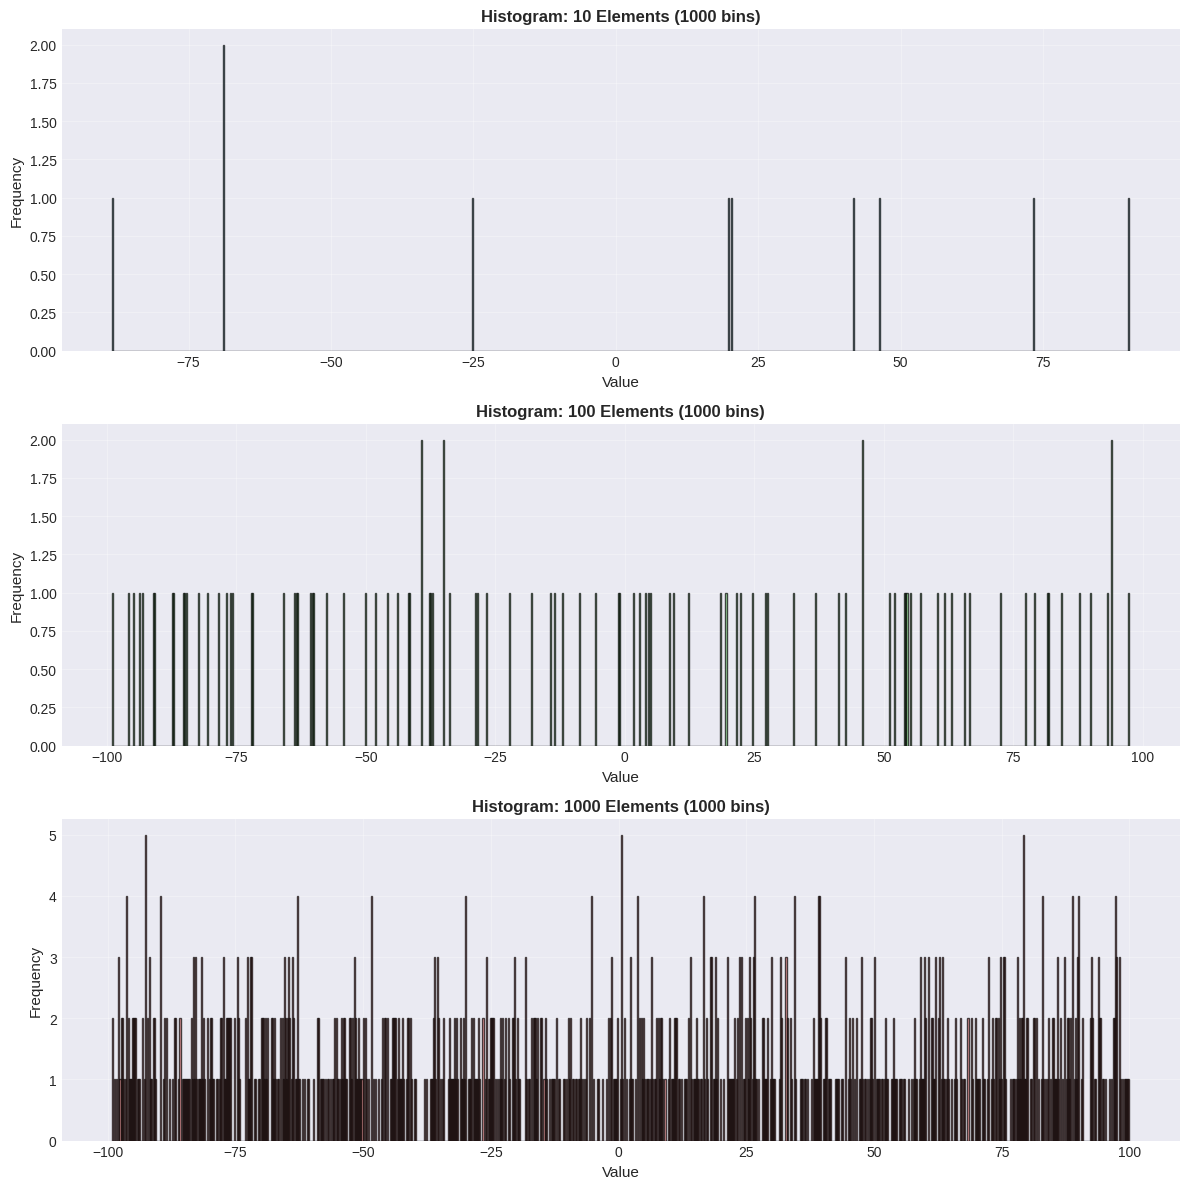

In [5]:
# Number of bins for all histograms
num_bins = 1000

# Create three separate histogram plots
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Histogram 1: 10 elements
axes[0].hist(array_10, bins=num_bins, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Value', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Histogram: 10 Elements (1000 bins)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histogram 2: 100 elements
axes[1].hist(array_100, bins=num_bins, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Value', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Histogram: 100 Elements (1000 bins)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Histogram 3: 1000 elements
axes[2].hist(array_1000, bins=num_bins, color='lightcoral', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Value', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Histogram: 1000 Elements (1000 bins)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part (c): Explanation of Results

#### How the histogram shape changes as the number of data points increases:

1. **10 Elements (Small Sample):**
   - The histogram appears extremely sparse and irregular
   - Most bins are empty (frequency = 0)
   - Only 10 bins out of 1000 contain data (one element per bin)
   - The distribution looks highly random with no clear pattern
   - Statistical fluctuations dominate the appearance

2. **100 Elements (Medium Sample):**
   - The histogram is still quite sparse but shows slightly better coverage
   - About 100 bins out of 1000 contain data
   - The distribution starts to show hints of uniformity, but with significant gaps
   - Random fluctuations are still very prominent
   - The "flat" nature of uniform distribution is not yet clearly visible

3. **1000 Elements (Large Sample):**
   - The histogram shows much better coverage across the range
   - Most bins now contain data points
   - The distribution begins to approach the expected flat, uniform shape
   - While still showing some randomness, the overall trend toward uniformity is evident
   - The Law of Large Numbers begins to take effect

#### Why a uniform distribution should look flat:

- In a **true uniform distribution**, every value in the range [-100, 100] has an **equal probability** of being selected
- This means that over many samples, each bin should receive approximately the same number of data points
- The histogram of a perfect uniform distribution would show a constant height across all bins
- Mathematically, the probability density function (PDF) of a uniform distribution is constant

#### How randomness affects small vs. large datasets:

1. **Small Datasets (N = 10):**
   - Random fluctuations completely dominate
   - The sample is too small to represent the underlying uniform distribution
   - Each random draw significantly affects the overall shape
   - Cannot reliably infer the true distribution from such a small sample

2. **Large Datasets (N = 1000):**
   - Random fluctuations average out over many samples
   - The **Law of Large Numbers** ensures that the sample distribution converges to the true distribution
   - Individual random variations become less significant relative to the overall pattern
   - The histogram reliably reflects the uniform nature of the underlying distribution

**Conclusion:** As sample size increases, the empirical distribution (histogram) approaches the theoretical distribution (flat for uniform). This demonstrates a fundamental principle of statistics: larger samples provide better estimates of population characteristics.

---
# Question 3: Variable Thermal Conductivity (Class-based Approach)

In this problem, we model a rod where thermal conductivity varies with position: **k(x) = a + b·x**

The temperature distribution is calculated using thermal resistance concepts and numerical integration.

### Part (a): Create ThermalRod Class

In [6]:
class ThermalRod:
    """
    A class to model heat transfer in a rod with variable thermal conductivity.

    The thermal conductivity varies as: k(x) = a + b*x
    where x is the position along the rod.

    Attributes:
    -----------
    a : float
        Constant term in thermal conductivity (> 0)
    b : float
        Linear coefficient in thermal conductivity (> 0)
    L : float
        Length of the rod in meters
    T_left : float
        Temperature at x=0 (boundary condition)
    T_right : float
        Temperature at x=L (boundary condition)
    """

    def __init__(self, a, b, L=1.0, T_left=0, T_right=100):
        """
        Initialize the ThermalRod with thermal conductivity parameters.

        Parameters:
        -----------
        a : float
            Constant term in k(x) = a + b*x (must be > 0)
        b : float
            Linear coefficient in k(x) = a + b*x (must be > 0)
        L : float, optional
            Length of rod in meters (default = 1.0 m)
        T_left : float, optional
            Temperature at x=0 in Kelvin (default = 0 K)
        T_right : float, optional
            Temperature at x=L in Kelvin (default = 100 K)
        """
        if a <= 0 or b <= 0:
            raise ValueError("Both a and b must be greater than zero")

        self.a = a
        self.b = b
        self.L = L
        self.T_left = T_left
        self.T_right = T_right

        # Calculate total thermal resistance for the entire rod
        self.R_total = self._calculate_thermal_resistance(0, self.L)

    def _thermal_conductivity(self, x):
        """
        Calculate thermal conductivity at position x.

        k(x) = a + b*x
        """
        return self.a + self.b * x

    def _thermal_resistance_integrand(self, x):
        """
        Integrand for thermal resistance calculation: 1/k(x)

        Thermal resistance: R = ∫[1/k(x)]dx
        """
        return 1.0 / self._thermal_conductivity(x)

    def _calculate_thermal_resistance(self, x1, x2):
        """
        Calculate thermal resistance between positions x1 and x2.

        Uses numerical integration (scipy.integrate.quad)
        """
        resistance, _ = integrate.quad(self._thermal_resistance_integrand, x1, x2)
        return resistance

    def get_temperature(self, x):
        """
        Calculate temperature at position x along the rod.

        Uses the thermal resistance ratio method:
        T(x) = T_left + (T_right - T_left) * [R(0,x) / R(0,L)]

        Where:
        - R(0,x) is thermal resistance from 0 to x
        - R(0,L) is total thermal resistance

        Parameters:
        -----------
        x : float or array
            Position(s) along the rod in meters

        Returns:
        --------
        temperature : float or array
            Temperature at position x in Kelvin
        """
        # Handle both scalar and array inputs
        if isinstance(x, (list, np.ndarray)):
            temperatures = np.array([self._get_single_temperature(xi) for xi in x])
            return temperatures
        else:
            return self._get_single_temperature(x)

    def _get_single_temperature(self, x):
        """
        Calculate temperature at a single position x.
        """
        if x < 0 or x > self.L:
            raise ValueError(f"Position x must be between 0 and {self.L}")

        # Calculate thermal resistance from left end (x=0) to position x
        R_partial = self._calculate_thermal_resistance(0, x)

        # Temperature rises proportionally to the resistance ratio
        temperature = self.T_left + (self.T_right - self.T_left) * (R_partial / self.R_total)

        return temperature

# Test the class
print("ThermalRod class created successfully!")
print("\nTesting with sample parameters:")
test_rod = ThermalRod(a=1.0, b=0.5, L=1.0, T_left=0, T_right=100)
print(f"Temperature at x=0.0 m: {test_rod.get_temperature(0.0):.2f} K")
print(f"Temperature at x=0.5 m: {test_rod.get_temperature(0.5):.2f} K")
print(f"Temperature at x=1.0 m: {test_rod.get_temperature(1.0):.2f} K")

ThermalRod class created successfully!

Testing with sample parameters:
Temperature at x=0.0 m: 0.00 K
Temperature at x=0.5 m: 55.03 K
Temperature at x=1.0 m: 100.00 K


### Part (b): Plot Temperature vs Position

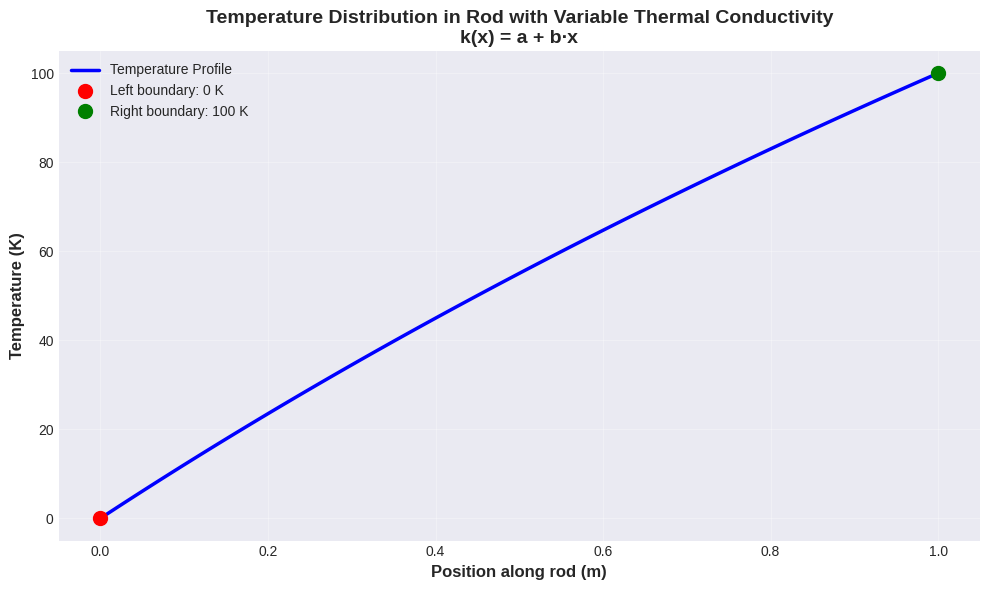


Temperature Distribution Statistics:
Minimum temperature: 0.00 K at x = 0.00 m
Maximum temperature: 100.00 K at x = 1.00 m
Temperature at midpoint (x=0.5m): 55.03 K

Note: The non-linear temperature profile is due to variable thermal conductivity.


In [7]:
# Given parameters
a = 1.0  # Constant term in k(x)
b = 0.5  # Linear coefficient in k(x)
L = 1.0  # Length of rod in meters
T_left = 0    # Temperature at x=0 (K)
T_right = 100 # Temperature at x=L (K)

# Create ThermalRod instance
rod = ThermalRod(a=a, b=b, L=L, T_left=T_left, T_right=T_right)

# Generate x-values from 0 to 1 meter with 1 cm resolution
x_positions = np.arange(0, 1.01, 0.01)  # 0 to 1 m with 0.01 m steps

# Calculate temperatures at all positions
temperatures = rod.get_temperature(x_positions)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x_positions, temperatures, 'b-', linewidth=2.5, label='Temperature Profile')
plt.xlabel('Position along rod (m)', fontsize=12, fontweight='bold')
plt.ylabel('Temperature (K)', fontsize=12, fontweight='bold')
plt.title('Temperature Distribution in Rod with Variable Thermal Conductivity\nk(x) = a + b·x',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Add boundary condition markers
plt.plot(0, T_left, 'ro', markersize=10, label=f'Left boundary: {T_left} K')
plt.plot(L, T_right, 'go', markersize=10, label=f'Right boundary: {T_right} K')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"\nTemperature Distribution Statistics:")
print(f"Minimum temperature: {temperatures.min():.2f} K at x = {x_positions[temperatures.argmin()]:.2f} m")
print(f"Maximum temperature: {temperatures.max():.2f} K at x = {x_positions[temperatures.argmax()]:.2f} m")
print(f"Temperature at midpoint (x=0.5m): {rod.get_temperature(0.5):.2f} K")
print(f"\nNote: The non-linear temperature profile is due to variable thermal conductivity.")

---
# Question 4: Heat Transfer and Phase Change (Calorimetry)

This problem involves mixing hot water with ice and determining whether the ice fully melts or not.

### Part (a): Create Dictionary of Specific Heat Capacities

In [8]:
# Dictionary of specific heat capacities in J/(kg·K)
specific_heat_capacities = {
    'water': 4180,      # J/(kg·K)
    'iron': 483,        # J/(kg·K)
    'copper': 399,      # J/(kg·K)
    'aluminum': 882     # J/(kg·K)
}

# Display the dictionary
print("Specific Heat Capacities [J/(kg·K)]:")
print("=" * 40)
for material, capacity in specific_heat_capacities.items():
    print(f"{material.capitalize():12s}: {capacity:6d} J/(kg·K)")

print("\n" + "=" * 40)

Specific Heat Capacities [J/(kg·K)]:
Water       :   4180 J/(kg·K)
Iron        :    483 J/(kg·K)
Copper      :    399 J/(kg·K)
Aluminum    :    882 J/(kg·K)



### Part (b): Mixing Hot Water with Ice Function

In [9]:
def mix_water_with_ice(M, T, m, c_water=4180, L_fusion=334000):
    """
    Simulate mixing hot water with ice at 0°C.

    This function calculates whether ice completely melts or not,
    and returns either the mass of ice melted or the final equilibrium temperature.

    Parameters:
    -----------
    M : float
        Mass of hot water in kg
    T : float
        Initial temperature of hot water in °C
    m : float
        Mass of ice in kg (at 0°C)
    c_water : float, optional
        Specific heat capacity of water in J/(kg·K) (default = 4180)
    L_fusion : float, optional
        Latent heat of fusion of ice in J/kg (default = 334,000)

    Returns:
    --------
    result : dict
        Dictionary containing:
        - 'scenario': 'partial_melt' or 'complete_melt'
        - 'mass_melted': mass of ice melted (kg) if partial melt
        - 'final_temperature': equilibrium temperature (°C) if complete melt
        - 'heat_available': heat available from water (J)
        - 'heat_to_melt_all': heat needed to melt all ice (J)

    Physics:
    --------
    Heat lost by water = M * c_water * (T - T_final)
    Heat to melt ice = m_melted * L_fusion
    Heat to warm melted ice = m_melted * c_water * (T_final - 0)

    Two scenarios:
    1. Partial melt: Not enough heat to melt all ice
       → Final temperature = 0°C, some ice remains
    2. Complete melt: Enough heat to melt all ice
       → All ice melts, final temperature > 0°C
    """

    # Calculate heat available from hot water cooling to 0°C
    heat_available = M * c_water * T

    # Calculate heat required to melt all ice (without warming it)
    heat_to_melt_all_ice = m * L_fusion

    print(f"\n{'='*60}")
    print(f"MIXING SIMULATION")
    print(f"{'='*60}")
    print(f"Hot water: {M} kg at {T}°C")
    print(f"Ice: {m} kg at 0°C")
    print(f"\nHeat available from water: {heat_available:,.2f} J")
    print(f"Heat needed to melt all ice: {heat_to_melt_all_ice:,.2f} J")
    print(f"{'='*60}\n")

    # Scenario 1: NOT enough heat to melt all ice (Partial Melt)
    if heat_available < heat_to_melt_all_ice:
        # Calculate how much ice can be melted
        mass_melted = heat_available / L_fusion

        print("SCENARIO: PARTIAL MELT")
        print(f"The ice does NOT completely melt.")
        print(f"\nMass of ice that melted: {mass_melted:.4f} kg")
        print(f"Mass of ice remaining: {m - mass_melted:.4f} kg")
        print(f"Final equilibrium temperature: 0°C")
        print(f"\nExplanation: The hot water loses all its heat to partially")
        print(f"melt the ice. The final mixture is at 0°C with both water and ice present.")

        return {
            'scenario': 'partial_melt',
            'mass_melted': mass_melted,
            'mass_remaining': m - mass_melted,
            'final_temperature': 0.0,
            'heat_available': heat_available,
            'heat_to_melt_all': heat_to_melt_all_ice
        }

    # Scenario 2: Enough heat to melt all ice (Complete Melt)
    else:
        # All ice melts, remaining heat warms the melted ice water
        heat_remaining = heat_available - heat_to_melt_all_ice

        # Final temperature calculation using energy balance
        # Heat lost by hot water = Heat to melt ice + Heat to warm melted ice
        # M*c*(T - T_f) = m*L_fusion + m*c*(T_f - 0)
        # Solving for T_f:
        final_temperature = (M * c_water * T - m * L_fusion) / ((M + m) * c_water)

        print("SCENARIO: COMPLETE MELT")
        print(f"All ice melts completely!")
        print(f"\nMass of ice melted: {m:.4f} kg (all of it)")
        print(f"Heat used to melt ice: {heat_to_melt_all_ice:,.2f} J")
        print(f"Heat remaining to warm melted ice: {heat_remaining:,.2f} J")
        print(f"\nFinal equilibrium temperature: {final_temperature:.2f}°C")
        print(f"\nExplanation: The hot water has enough heat to melt all the ice")
        print(f"and warm the resulting water. Final mixture is all liquid at {final_temperature:.2f}°C.")

        return {
            'scenario': 'complete_melt',
            'mass_melted': m,
            'final_temperature': final_temperature,
            'heat_available': heat_available,
            'heat_to_melt_all': heat_to_melt_all_ice,
            'heat_remaining': heat_remaining
        }

# Test the function with different scenarios
print("\n" + "#"*60)
print("# TEST CASE 1: Partial Melt Scenario")
print("#"*60)
result1 = mix_water_with_ice(M=0.5, T=50, m=2.0)

print("\n\n" + "#"*60)
print("# TEST CASE 2: Complete Melt Scenario")
print("#"*60)
result2 = mix_water_with_ice(M=2.0, T=80, m=0.5)


############################################################
# TEST CASE 1: Partial Melt Scenario
############################################################

MIXING SIMULATION
Hot water: 0.5 kg at 50°C
Ice: 2.0 kg at 0°C

Heat available from water: 104,500.00 J
Heat needed to melt all ice: 668,000.00 J

SCENARIO: PARTIAL MELT
The ice does NOT completely melt.

Mass of ice that melted: 0.3129 kg
Mass of ice remaining: 1.6871 kg
Final equilibrium temperature: 0°C

Explanation: The hot water loses all its heat to partially
melt the ice. The final mixture is at 0°C with both water and ice present.


############################################################
# TEST CASE 2: Complete Melt Scenario
############################################################

MIXING SIMULATION
Hot water: 2.0 kg at 80°C
Ice: 0.5 kg at 0°C

Heat available from water: 668,800.00 J
Heat needed to melt all ice: 167,000.00 J

SCENARIO: COMPLETE MELT
All ice melts completely!

Mass of ice melted: 0.5000 kg (all 

### Additional Examples and Verification

In [10]:
# Example 3: Exactly enough heat to melt all ice
print("\n" + "#"*60)
print("# TEST CASE 3: Borderline Case")
print("#"*60)
# Calculate M and T such that heat is exactly enough to melt 1 kg of ice
m_ice = 1.0  # kg
heat_needed = m_ice * 334000  # Heat to melt 1 kg
M_water = 2.0  # kg
T_water = heat_needed / (M_water * 4180)  # Temperature needed
print(f"\nTo just barely melt {m_ice} kg of ice, {M_water} kg of water needs to be at {T_water:.2f}°C")
result3 = mix_water_with_ice(M=M_water, T=T_water, m=m_ice)

# Summary table
print("\n\n" + "="*60)
print("SUMMARY OF ALL TEST CASES")
print("="*60)
print(f"{'Test Case':<15} {'Scenario':<20} {'Result':<25}")
print("-"*60)
print(f"{'Case 1':<15} {result1['scenario']:<20} {f"{result1['mass_melted']:.4f} kg melted":<25}")
print(f"{'Case 2':<15} {result2['scenario']:<20} {f"{result2['final_temperature']:.2f}°C final temp":<25}")
print(f"{'Case 3':<15} {result3['scenario']:<20} {f"{result3['final_temperature']:.2f}°C final temp":<25}")
print("="*60)


############################################################
# TEST CASE 3: Borderline Case
############################################################

To just barely melt 1.0 kg of ice, 2.0 kg of water needs to be at 39.95°C

MIXING SIMULATION
Hot water: 2.0 kg at 39.952153110047846°C
Ice: 1.0 kg at 0°C

Heat available from water: 334,000.00 J
Heat needed to melt all ice: 334,000.00 J

SCENARIO: COMPLETE MELT
All ice melts completely!

Mass of ice melted: 1.0000 kg (all of it)
Heat used to melt ice: 334,000.00 J
Heat remaining to warm melted ice: 0.00 J

Final equilibrium temperature: 0.00°C

Explanation: The hot water has enough heat to melt all the ice
and warm the resulting water. Final mixture is all liquid at 0.00°C.


SUMMARY OF ALL TEST CASES
Test Case       Scenario             Result                   
------------------------------------------------------------
Case 1          partial_melt         0.3129 kg melted         
Case 2          complete_melt        48.02°C fina